# Environment Setup

In [ ]:
# %pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset
import numpy as np
import pandas as pd
import seaborn as sns
# %pip install colorcet
import colorcet as cc
from scipy import interpolate
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import *
# %pip install captum
import captum

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["mathtext.fontset"]= 'cm'  # Use Computer Modern for math
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

In [ ]:
# Set working directory
%cd C:/Your/Path/Here

C:\Users\10233\Box\Research\Resources\Sensor


## Utilities

In [ ]:
def generate_data_with_correlation(X, target_corr, random_seed=None):
    """
    Generate a new dataset Y with a specific correlation coefficient with X.

    Parameters:
        X (array-like): Original dataset.
        target_corr (float): Desired correlation coefficient (-1 to 1).
        random_seed (int, optional): Seed for reproducibility.

    Returns:
        Y (numpy.ndarray): Generated dataset with the specified correlation coefficient.
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Standardize X
    X = np.array(X)
    X_std = (X - np.mean(X)) / np.std(X)

    # Generate random Y
    Y_random = np.random.randn(len(X))
    Y_random_std = (Y_random - np.mean(Y_random)) / np.std(Y_random)

    # Create Y with the desired correlation
    Y = target_corr * X_std + np.sqrt(1 - target_corr**2) * Y_random_std

    # Scale Y back to match X's mean and standard deviation if needed
    Y = Y * np.std(X) + np.mean(X)

    return Y

In [ ]:
def generate_data_with_correlation_2d(X, R, random_seed=None):
    """
    Generate a dataset Y with specific correlation coefficients with multiple given datasets.

    Parameters:
        X (numpy.ndarray): A 2D array of shape (n_datasets, n_datapoints), where each row is a dataset.
        R (array-like): Desired correlation coefficients for each dataset in X (1D array of length n_datasets).
        random_seed (int, optional): Random seed for reproducibility.

    Returns:
        Y (numpy.ndarray): Generated dataset with the desired correlation coefficients with each row of X.
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Ensure X is a numpy array and has the correct shape
    X = np.asarray(X)
    n_datasets, n_datapoints = X.shape

    if len(R) != n_datasets:
        raise ValueError("The length of R must match the number of rows in X.")

    # Standardize each row in X to have zero mean and unit variance
    X_std = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

    # Generate a random component orthogonal to all rows in X
    random_component = np.random.randn(n_datapoints)
    random_component = (random_component - np.mean(random_component)) / np.std(random_component)

    for i in range(n_datasets):
        # Orthogonalize the random component with respect to each row of X
        random_component -= np.dot(random_component, X_std[i]) * X_std[i] / np.dot(X_std[i], X_std[i])

    # Normalize the random component
    random_component = random_component / np.std(random_component)

    # Combine the standardized datasets in X and the random component to create Y
    Y = np.zeros(n_datapoints)
    for i in range(n_datasets):
        Y += R[i] * X_std[i]

    if np.sum(np.array(R)**2) < 1:
      Y += np.sqrt(1 - np.sum(np.array(R)**2)) * random_component
    else:
      print('Magnitude > 1. Random noise not added.')

    return Y

In [ ]:
# SET PARAMETERS HERE

# Load OSL
with open("Data/OSL", "rb") as fp:   # Unpickling
  OSL = pickle.load(fp)

n_sensors = 10
sensors = range(1,377)
test_model = 0
# sensors = np.array([197,6,215,18,237,0,260,279,191,35])+1 # 10 IG sensors using Affinity Propogation clustering
# sensors = OSL["Attr_LSTM_Greedy"][:n_sensors]
# sensors = OSL["Attr_LSTM_12_10"][:n_sensors]
# sensors = OSL["uniform_"+str(n_sensors)]
# sensors = OSL["POD_123_"+str(n_sensors)]
# sensors = OSL["bayes_"+str(n_sensors)]

# sensors = OSL["Attr_LSTM_12_Cylinder2-0"][:n_sensors]
# sensors = OSL["POD_4_Cylinder2-0"]

sensors = np.array(sensors)-1
case_list = [0,1,2,3,4] # Validation Case
train_index = [0,1,2]
nt_train = 30000 # cannot exceed 11000
nt_val = 10000
n_augment = [0,0,0] # number of times to repeat the data for each case for augmentation

# n_pred == 0 for CL reconstruction
n_pred = 0
n_P = 1
interval = 0.0025 # interval between time steps

# filename = "uniform_"+str(n_sensors)
# filename = "Attr_Greedy_"+str(n_sensors)
# filename = "POD_"+str(n_sensors)
filename = "Bayes_"+str(n_sensors)


if len(train_index) == 1:
  folder_name = str(interval)+"_spaced/"+str(n_P)+"-"+str(n_pred)+"/indv_case"
else:
  folder_name = str(interval)+"_spaced/"+str(n_P)+"-"+str(n_pred)+"/train-"+''.join(map(str, np.array(train_index)+1))
# folder_name = str(interval)+"_spaced/Attr"

# "0" if normalized by sensors, "None" if normalized by case
NorBy = 0

P_inter = 'cubic'
CL_inter = 'cubic'

RuntimeError: empty_like method already has a different docstring

In [ ]:
def create_dataset(x_in, y_in, lookback, pred_window):
    """Transform a time series into a prediction dataset

    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
        pred_window: Size of window to predict (should be smaller than lookback)
    """
    n_output = len(x_in) - lookback - pred_window + 1
    # stop = len(x_in) - lookback + 1
    X, y = np.zeros((n_output,lookback,len(sensors))), np.zeros((n_output,lookback,1))
    for i in range(n_output):
        feature = x_in[i:i+lookback,:]
        # target = y_in[i+lookback:i+lookback+pred_window]
        target = y_in[i+pred_window:i+lookback+pred_window]
        X[i,:,:] = feature
        y[i,:,0] = target
    return X, y

In [ ]:
# Load Training Data
datasets = ["airfoil_5","airfoil_11","cylinder_5","cylinder_11","cylinder_0_5_1"]
n_grids = [188,188,188,208,208]

P_all = np.array([],ndmin=3)
CL = np.array([],ndmin=3)
# nt_train_list = [2880,9160,9730]
for i in train_index:
  # nt_train = nt_train_list[i]
  data1 = np.genfromtxt("Data/"+datasets[i]+"_wall1_surfacepressure_span.dat",delimiter = ',',usecols=range(n_grids[i]+1))

  df = pd.read_csv("Data/"+datasets[i]+"_CL.csv")
  CL_data = df.to_numpy()
  time_CL = CL_data[:,0]

  time_raw = time_CL[np.arange(3,len(data1[:,0])*4,4)] # get raw time data for pressure from CL data (per 4 entries)
  time_spaced = np.arange(time_raw[0],time_raw[-1],interval) # linear time space with interval
  print('Available data points for case %i =' % (i),time_spaced.size)

  time = time_spaced[:nt_train]

  # interpolate pressure to linear time space
  P1_raw = data1[:,1:]
  f = interpolate.interp1d(time_raw, P1_raw, kind='cubic', axis=0)
  P1_spaced = f(time_spaced)
  P_temp=P1_spaced[:nt_train,:]

  coord1 = np.genfromtxt("Data/"+datasets[2]+"_xy_sort_wall1.dat",delimiter = ',')
  nx = coord1[0,0].astype(int)
  coord1 = coord1[1:nx+1,:]
  X1=coord1[:,0] # X,Y coordinates in ascending order
  Y1=coord1[:,1]

  data2 = np.genfromtxt("Data/"+datasets[i]+"_wall2_surfacepressure_span.dat",delimiter = ',',usecols=range(n_grids[i]+1))
  # interpolate pressure to linear time space
  P2_raw = data2[:,1:]
  f = interpolate.interp1d(time_raw, P2_raw, kind='cubic', axis=0)
  P2_spaced = f(time_spaced)
  P2_temp=P2_spaced[:nt_train,:]

  coord2 = np.loadtxt("Data/"+datasets[2]+"_xy_sort_wall2.dat",skiprows=1)
  coord2 = coord2[0:nx,:]
  X2=coord2[:,0] # X,Y coordinates in ascending order
  Y2=coord2[:,1]

  CL_pre = CL_data[:,1]
  CL_interp= interpolate.interp1d(time_CL, CL_pre, kind=CL_inter, fill_value='extrapolate')
  CL_temp = CL_interp(time)

  CL_nor = (CL_temp-np.mean(CL_temp))/(np.amax(CL_temp)-np.amin(CL_temp)) # Normalization by case

  coord_temp = np.genfromtxt("Data/"+datasets[i]+"_xy_sort_wall1.dat",delimiter = ',')
  nx_temp = coord_temp[0,0].astype(int)
  coord_temp = coord_temp[1:nx_temp+1,:]
  X_temp = coord_temp[:,0]

  f = interpolate.interp1d(X_temp, P_temp, kind=P_inter, axis=1, fill_value='extrapolate')
  P1 = f(X1)

  f2 = interpolate.interp1d(X_temp, P2_temp, kind=P_inter, axis=1, fill_value='extrapolate')
  P2 = f2(X2)

  P_temp = (np.hstack((P1,P2)))[:,sensors]

  P_nor = (P_temp-np.mean(P_temp,axis=NorBy))/(np.amax(P_temp,axis=NorBy)-np.amin(P_temp,axis=NorBy)) # Normalization by case

  P_train_stacked, CL_train_stacked = create_dataset(P_nor, CL_nor, lookback=n_P, pred_window = n_pred)

  if not np.any(P_all): # if P_all is empty
    P_all = P_train_stacked
    CL = CL_train_stacked
  else:
    P_all = np.vstack((P_all,P_train_stacked))
    CL = np.vstack((CL,CL_train_stacked))

  for k in range(n_augment[i]):
    P_all = np.vstack((P_all,P_train_stacked))
    CL = np.vstack((CL,CL_train_stacked))

  print("CL: ",np.shape(CL))
  print("P_all: ",np.shape(P_all))

Available data points for case 0 = 36214
CL:  (30000, 1, 1)
P_all:  (30000, 1, 376)
Available data points for case 1 = 40358
CL:  (60000, 1, 1)
P_all:  (60000, 1, 376)
Available data points for case 2 = 39374
CL:  (90000, 1, 1)
P_all:  (90000, 1, 376)


In [ ]:
# # Candidate attr increase demo
# P_cluster = np.squeeze(P_all,axis=1).T
# aff_matrix = np.abs(np.corrcoef(P_cluster))

# index = [182,180,19,370,375]

# print(P_cluster.shape)
# P_cluster = P_cluster[index,:]
# print(P_cluster.shape)

# # print(P_cluster.shape)

(376, 90000)
(5, 90000)


In [ ]:
# # Manually choose data with the desired correlation
# # Attr method demo
# Cov_desire = [0.75,0.5,0]

# P_cluster = np.squeeze(P_all,axis=1).T
# aff_matrix = np.abs(np.corrcoef(P_cluster))

# index = np.zeros(len(Cov_desire),dtype=int)
# for i in range(len(Cov_desire)):
#   index[i] = np.argmin(np.abs(aff_matrix[0,:] - Cov_desire[i]))
#   print(index[i],aff_matrix[0,index[i]])

# P_rand = np.random.rand(1,len(P_cluster[1]))
# print('CL correlation with random data =',np.corrcoef(P_rand,np.squeeze(CL))[0,1])
# print('1st sensor pressure correlation with random data =',np.corrcoef(P_cluster[0,:],P_rand)[0,1])

# print(P_cluster.shape)
# P_cluster = np.vstack((P_cluster[0,:],P_cluster[index,:],P_rand))
# print(P_cluster.shape)
# # P_cluster = np.expand_dims(P_cluster.T,axis=1)
# # print(P_cluster.shape)

19 0.7500440977641368
239 0.5000409388078926
173 0.0022118148539491535
CL correlation with random data = -0.0009819581905245987
1st sensor pressure correlation with random data = -0.0054257208552858744
(376, 90000)
(5, 90000)


# Create Generated Dataset

In [ ]:
# Data generation for "synthetic data sensor selection experiment"

random_seed=35
N = 10000 # number of datapoints
# P1 = generate_data_with_correlation(CL[:,0,0],0.7, random_seed=random_seed)
np.random.seed(None) 
P1 = np.random.rand(N)
# print('corr(CL) =',np.corrcoef(P1,np.squeeze(CL))[0,1])
P2 = generate_data_with_correlation(P1, 0.9, random_seed=random_seed)
print('corr(P1,P2) =',np.round(np.corrcoef(P1,P2)[0,1],3))

np.random.seed(None)
P3 = np.random.rand(N)
print('corr(P1,P3) =',np.round(np.corrcoef(P1,P3)[0,1],3))

P_cluster = np.vstack((P1,P2,P3))
print(P_cluster.shape)

CL = generate_data_with_correlation_2d(P_cluster, [0.7, 0.2, 0.3], random_seed=random_seed)
# print CL's correlation with every row in P_cluster
print('corr(CL, P1) =',np.round(np.corrcoef(CL,P1)[0,1],3))
print('corr(CL, P2) =',np.round(np.corrcoef(CL,P2)[0,1],3))
print('corr(CL, P3) =',np.round(np.corrcoef(CL,P3)[0,1],3))
print('Average CL =',np.mean(CL))
CL = np.expand_dims(CL,axis=(1,2))
print(CL.shape)

corr(P1,P2) = 0.901
corr(P1,P3) = -0.009
(3, 10000)
corr(CL, P1) = 0.653
corr(CL, P2) = 0.885
corr(CL, P3) = 0.312
Average CL = 2.1316282072803006e-17
(10000, 1, 1)


In [ ]:
# Data generation for "attribution variation with Corr(X3,Y)""

random_seed=35
N = 10000 # number of datapoints
# P1 = generate_data_with_correlation(CL[:,0,0],0.7, random_seed=random_seed)
np.random.seed(None)
P1 = np.random.rand(N)
# print('corr(CL) =',np.corrcoef(P1,np.squeeze(CL))[0,1])
P2 = generate_data_with_correlation(P1, 0.9, random_seed=random_seed)
print('corr(P1,P2) =',np.round(np.corrcoef(P1,P2)[0,1],3))

np.random.seed(None)
P3 = np.random.rand(N)
print('corr(P1,P3) =',np.round(np.corrcoef(P1,P3)[0,1],3))

P_cluster = np.vstack((P1,P2,P3))
print(P_cluster.shape)

CL = generate_data_with_correlation_2d(P_cluster, [0.7, 0.0, 0.3], random_seed=random_seed)
# print CL's correlation with every row in P_cluster
print('corr(CL, P1) =',np.round(np.corrcoef(CL,P1)[0,1],3))
print('corr(CL, P2) =',np.round(np.corrcoef(CL,P2)[0,1],3))
print('corr(CL, P3) =',np.round(np.corrcoef(CL,P3)[0,1],3))
print('Average CL =',np.mean(CL))
CL = np.expand_dims(CL,axis=(1,2))
print(CL.shape)

corr(P1,P2) = 0.899
corr(P1,P3) = -0.017
(3, 10000)
corr(CL, P1) = 0.533
corr(CL, P2) = 0.809
corr(CL, P3) = 0.373
Average CL = -1.6981971384666395e-16
(10000, 1, 1)


In [ ]:
# AffinityPropagation Clustering
aff_matrix = np.abs(np.corrcoef(P_cluster)) # Compute affinity matrix using correlation coefficient
af = AffinityPropagation(damping=0.5,max_iter=10000, convergence_iter=10, copy=True, preference= 0.7, affinity='precomputed').fit(aff_matrix)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_
n_clusters_ = len(set(labels))
sensors = cluster_centers_indices
print(f'n_clusters = {n_clusters_}')
print(f'labels = {labels}')
print(f'cluster centers = {cluster_centers_indices}')

n_clusters = 2
labels = [0 0 1]
cluster centers = [0 2]


In [ ]:
sensors = cluster_centers_indices

In [ ]:
sensors = range(3)

# Model Training and Feature Attribution

Using device: cuda
sensors: range(0, 3)
Starting run 0
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3, out_features=4, bias=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Linear(in_features=4, out_features=4, bias=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Linear(in_features=4, out_features=4, bias=True)
  (6): LeakyReLU(negative_slope=0.01)
  (7): Linear(in_features=4, out_features=1, bias=True)
)
Train Epoch: 1/180  Train Loss: 1.1013e+00, Test Loss: 1.0613e+00, Learning Rate = 1.00e-04
Train Epoch: 11/180  Train Loss: 8.3678e-01, Test Loss: 7.6812e-01, Learning Rate = 1.00e-04
Train Epoch: 21/180  Train Loss: 1.0148e-01, Test Loss: 7.4155e-02, Learning Rate = 1.00e-04
Train Epoch: 31/180  Train Loss: 9.1994e-03, Test Loss: 7.1779e-03, Learning Rate = 1.00e-04
Train Epoch: 41/180  Train Loss: 2.2048e-03, Test Loss: 1.3711e-03, Learning Rate = 1.00e-04
Train Epoch: 51/180  Train Loss: 7.7049e-04, Test Loss: 3.5820e-04, Learning Rate = 1.00e

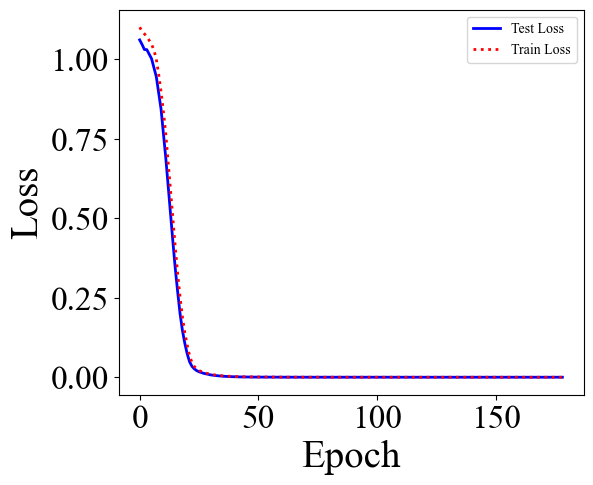

[1 2 0]
Absolute attributions: [-0.0343  1.46    1.0643]
Total attribution: 2.49
Percent attribution: [ 1. 57. 42.]


In [ ]:
n_iter = 1
use_GPU = True

if use_GPU:
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print(f"Using device: {device}")
  torch.cuda.empty_cache() # clear cuda memory

num_train = int(0.9 * len(CL))

print('sensors:',sensors)

P_temp = np.expand_dims(P_cluster.T,axis=1)
P_input = P_temp[:,:,sensors]

train_y = torch.squeeze(torch.tensor(CL[:num_train,:,:]), dim=2)
test_y = torch.squeeze(torch.tensor(CL[num_train:,:,:]), dim=2)

train_X = torch.tensor(P_input[:num_train,:,:])
test_X = torch.tensor(P_input[num_train:,:,:])

# make datasets and dataloaders
train_dataset = TensorDataset(train_X, train_y)
test_dataset = TensorDataset(test_X, test_y)

weights_mean_all = np.zeros([n_iter,len(sensors)])
for iter in range(n_iter):
  print('Starting run', iter)
  random_state = np.random.randint(0, 201)
  # set random seed
  torch.manual_seed(random_state)
  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
  test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

  # Model for testing sensor configurations

  layer_size = 4
  model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(len(sensors), layer_size,bias=True),
        # nn.BatchNorm1d(layer_size),
        nn.LeakyReLU(),
        nn.Linear(layer_size, layer_size,bias=True),
        # nn.BatchNorm1d(layer_size),
        nn.LeakyReLU(),
        nn.Linear(layer_size, layer_size,bias=True),
        # nn.BatchNorm1d(layer_size),
        nn.LeakyReLU(),
        nn.Linear(layer_size, 1,bias=True),
  )

  model = model.to(torch.double)
  if use_GPU: model.to(device)
  print(model)

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, min_lr=1e-7, eps=1e-8, patience=3)
  loss_fn = nn.MSELoss()
  # n_epochs = 20
  threshold = 1e-12   # early stopping threshold for test loss
  n_epochs_min = 30
  n_epochs_max = 180

  # store metrics
  training_loss_history = np.zeros([n_epochs_max, 1])
  validation_loss_history = np.zeros([n_epochs_max, 1])

  for epoch in range(n_epochs_max):
      model.train()
      for batch_idx, (data, target) in enumerate(train_loader):

          if use_GPU:
            data, target = data.to(device), target.to(device)
          # Erase accumulated gradients
          optimizer.zero_grad()

          # Forward pass
          # data = torch.squeeze(data)
          output = model(data)

          # Calculate loss
          loss = loss_fn(output, target)

          # Backward pass
          loss.backward()

          # Weight update
          optimizer.step()

          training_loss_history[epoch] += loss_fn(output, target).item()

      # Track loss each epoch
      training_loss_history[epoch] /= len(train_loader)
      if epoch % 10 == 0:
        print(f'Train Epoch: %d/%i  Train Loss: %1.4e' % (epoch + 1, n_epochs_max, training_loss_history[epoch,0]),end='')


      # Turning off automatic differentiation
      with torch.no_grad():
          model.eval()
          for data, target in test_loader:
              if use_GPU:
                  data, target = data.to(device), target.to(device)
              output = model(data)
              validation_loss_history[epoch] += loss_fn(output, target).item()  # Sum up batch loss

          validation_loss_history[epoch] /= len(test_loader)
          if epoch % 10 == 0:
            print(f', Test Loss: %1.4e' % validation_loss_history[epoch,0],end='')

      # loss_rate = (validation_loss_history[epoch-1]-validation_loss_history[epoch])/validation_loss_history[epoch]
      loss_rate = (training_loss_history[epoch-1]-training_loss_history[epoch])/training_loss_history[epoch]
      # if epoch > n_epochs_min and loss_rate < threshold: #loss_rate > 0 and
      #   break

      scheduler.step(validation_loss_history[epoch,0]) # adjust learning rate
      if epoch % 10 == 0:
        print(f', Learning Rate = %1.2e' % optimizer.param_groups[0]['lr'])

  plt.rcParams['figure.figsize'] = [6, 5] # change figure size
  plt.plot(validation_loss_history[:epoch], color='b',linewidth=2, label='Test Loss')
  plt.plot(training_loss_history[:epoch],':',color='r',linewidth=2, label='Train Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  # Compute attribution value by inputting validation data
  ig = captum.attr.IntegratedGradients(model)

  P_test_shap = torch.tensor(P_input)
  P_test_shap.requires_grad_()
  if use_GPU:
    P_test_shap = P_test_shap.to(device)

  attr = ig.attribute(P_test_shap,target=0,n_steps=50)
  if use_GPU:
    attr = attr.cpu()
  attr = attr.detach().numpy()

  # Compute mean attribution value for each candidate sensor
  # attr_avg_n_P = np.mean(abs(attr),axis=1)  # average over pressure history steps (2nd axis)
  attr_avg_n_P = np.mean((attr),axis=1)  # average over pressure history steps (2nd axis)
  weights_mean_all[iter,:] = np.mean(attr_avg_n_P,axis=0) # average over time samples (1st axis)

weights_mean = np.mean(weights_mean_all,axis=0) # average over iterations
sensor_temp = np.flip(np.argsort(weights_mean))
print(sensor_temp)

print('Absolute attributions:',np.round(weights_mean,4))
print('Total attribution:',np.round(np.sum(weights_mean),4))
print('Percent attribution:',np.round(abs(weights_mean)/np.sum(abs(weights_mean))*100,0))

# Plotting

In [ ]:
X=[0.1,0.2,0.31,0.58,0.75]
inv_attr = [4,8,12,20,26]
cand_attr = [9,20,28,48,63]

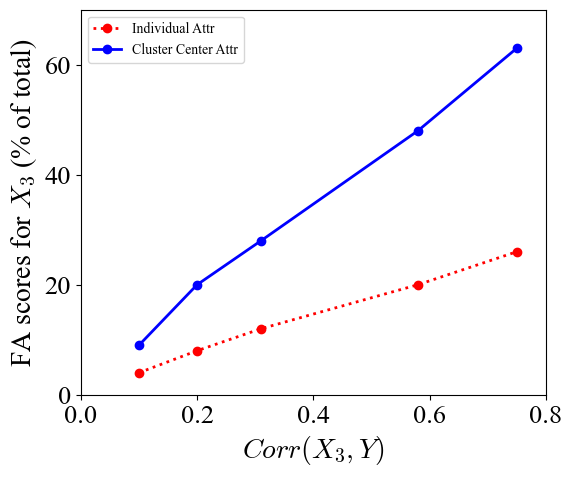

In [ ]:
plt.rcParams['figure.figsize'] = [6, 5] # change figure size
plt.plot(X, inv_attr,':', color='r',linewidth=2, label='Individual Attr',marker='o')
plt.plot(X,cand_attr,'-',color='b',linewidth=2, label='Cluster Center Attr',marker='o')
plt.xlabel('$Corr(X_3,Y)$',fontsize=20)
plt.ylabel('FA scores for $X_3$ (% of total)',fontsize=20)
plt.xlim([0,0.8])
plt.ylim([0,70])
plt.xticks(np.arange(0,0.9,0.2),fontsize=19)
plt.yticks(range(0,71,20),fontsize=19)
plt.savefig("Attr_variation_demo.eps",format='eps',bbox_inches='tight')
plt.savefig("Attr_variation_demo.png",bbox_inches='tight')
plt.legend()
plt.show()